# OT-2 run 20260701-111

The 14.5 s fuel-rich qualification burn, and the only OT run worth this much
attention. It holds one steady operating point for the whole burn, and once the
load cell is understood it measures everything needed to close that point.

`run_ot2_111.py` is the narrated version. This is the scratchpad.

**What the rig does not have:** a flow meter on the water side, and a torque
sensor on the shaft. Sections 3 and 4 recover both from what it does have.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

TESTBED = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TESTBED))
DATA = TESTBED / "data"

from campaigns import ot2
from otp.core.states import GasState, LiquidState
from otp.core.units import BAR, g, rpm_to_rad
from otp.experiments.loaders.airborne import load_run
from otp.experiments.records import SteadyWindow
from otp.experiments.reduce import reduce_point, reduce_series
from otp.experiments.acoustics import (compute_spectrogram, rpm_from_ridge,
                                       align_to_channel)
from otp.compare.predict import compare_turbine
from otp.turbine.analysis import Turbine

BURN = (2.0, 13.0)
run = load_run(DATA / "OT-2" / "20260701-111.h5", ot2.CHANNEL_MAP, ot2.RIG,
               notes=ot2.RUNS["20260701-111"])
print(run.notes)

fuel rich 15 s qualification burn
  dropped: p_water_supply [PT140 PT140 Water Supply] -- flat: 0.0118 span on a level of -11.8
  dropped: p_water_return [PT141 PT141 Water Return] -- median absolute pressure -8.99 bar is below vacuum


## 1 - What the rig recorded

Two channels get dropped on load and it is worth knowing why: PT140 sits flat at
-11.8 bar(g) and PT141 at -10.0 bar(g). Both are unplugged, not measuring.

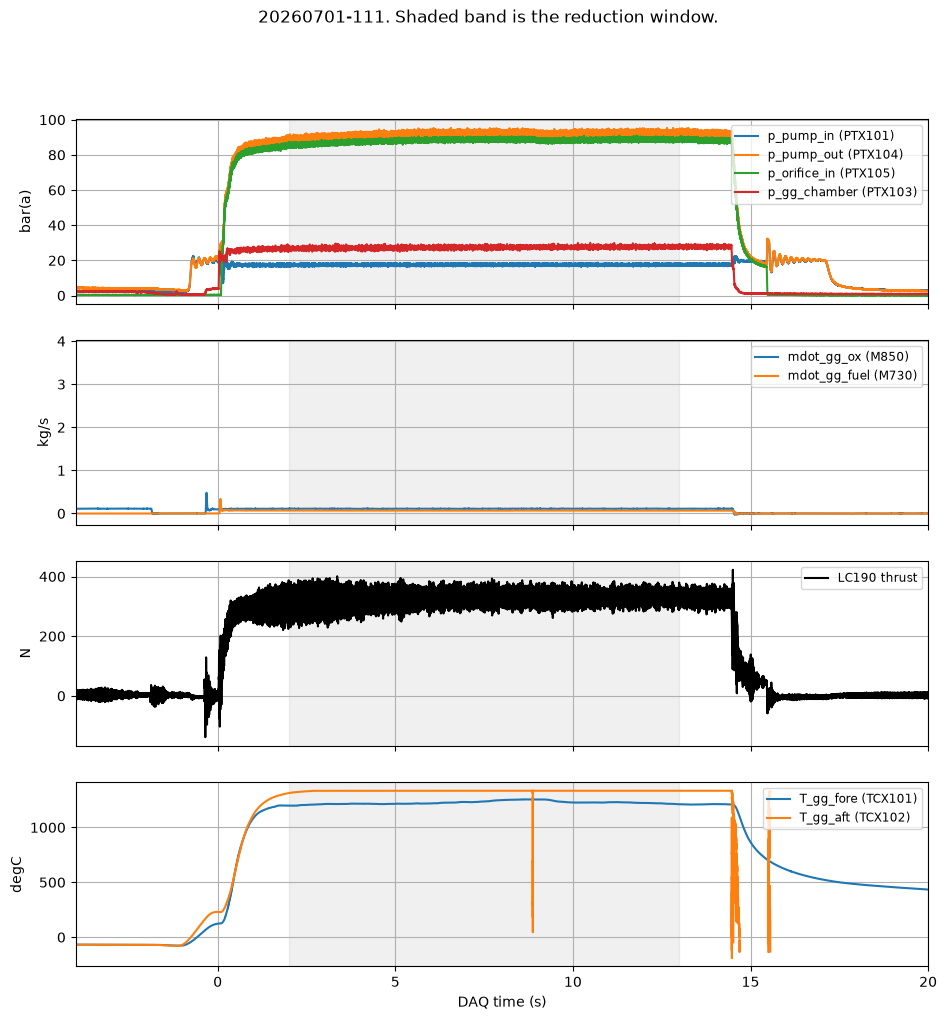

In [2]:
fig, axs = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

for n in ("p_pump_in", "p_pump_out", "p_orifice_in", "p_gg_chamber"):
    axs[0].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[0].set_ylabel("bar(a)")

for n in ("mdot_gg_ox", "mdot_gg_fuel"):
    axs[1].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[1].set_ylabel("kg/s")

axs[2].plot(run["thrust"].t, run["thrust"].v, "k", label="LC190 thrust")
axs[2].set_ylabel("N")

for n in ("T_gg_fore", "T_gg_aft"):
    axs[3].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[3].set_ylabel("degC"); axs[3].set_xlabel("DAQ time (s)")

for ax in axs:
    ax.grid(True); ax.legend(fontsize="small", loc="upper right")
    ax.axvspan(*BURN, color="k", alpha=0.06)
axs[0].set_xlim(-4, 20)
fig.suptitle("20260701-111. Shaded band is the reduction window.");

## 2 - Shaft speed, from the blade tone

35 rotor blades, so rpm = 60 f / 35. The setting that decides whether this works
is `whiten`: the stand's broadband noise near 8-9 kHz sits about 10 dB **above**
the 17 kHz blade tone, so a plain peak-pick locks onto the noise floor.

5-13 s: 29806 +/- 50 rpm (0.17%)
spectrogram bin = 9.2 rpm, so most of that scatter is resolution


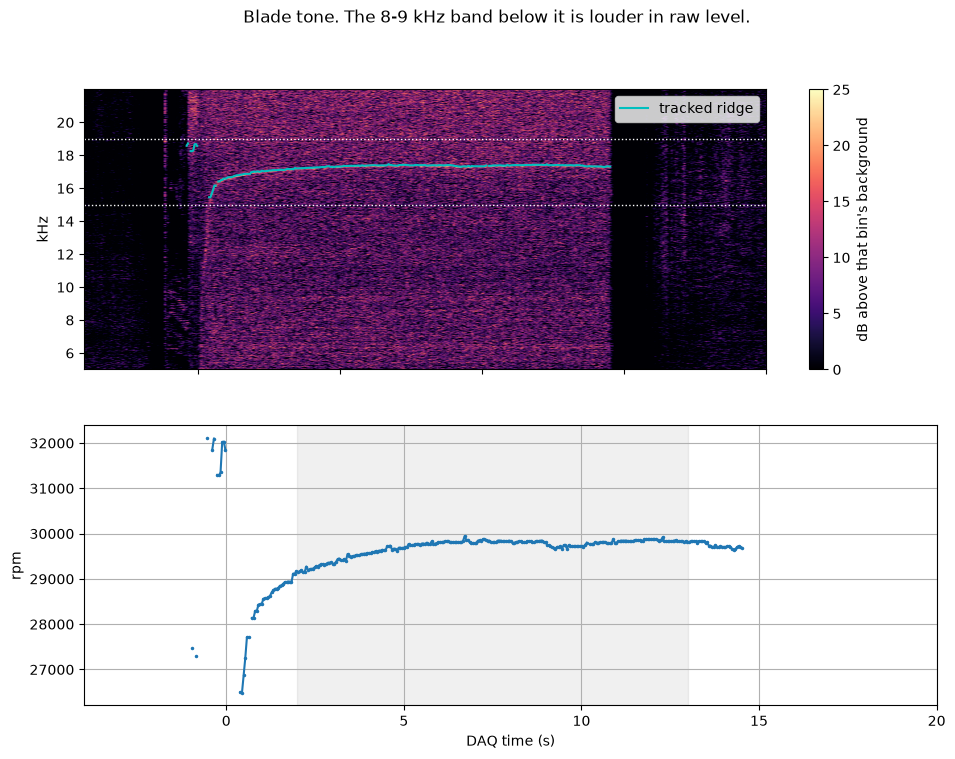

In [3]:
spec = compute_spectrogram(DATA / "OT-2" / ot2.AUDIO_FILE,
                           t_offset=ot2.AUDIO_T_OFFSET, nperseg=8192)
rpm_ch, prom = rpm_from_ridge(spec, ot2.AUDIO_BAND_HZ, ot2.EVENTS_PER_REV,
                              min_prominence_db=ot2.AUDIO_MIN_PROMINENCE_DB,
                              max_jump_hz=ot2.AUDIO_MAX_JUMP_HZ)
run.add(rpm_ch)
ok = np.isfinite(rpm_ch.v)

fig, axs = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
whitened = spec.db - np.median(spec.db, axis=1, keepdims=True)
sel = (spec.f > 5_000) & (spec.f < 22_000)
im = axs[0].pcolormesh(spec.t, spec.f[sel] / 1000, whitened[sel],
                       shading="gouraud", cmap="magma", vmin=0, vmax=25)
axs[0].plot(rpm_ch.t, rpm_ch.v * ot2.EVENTS_PER_REV / 60 / 1000, "c-", lw=1.5,
            label="tracked ridge")
for edge in ot2.AUDIO_BAND_HZ:
    axs[0].axhline(edge / 1000, color="w", ls=":", lw=1)
axs[0].set_ylabel("kHz"); axs[0].legend(loc="upper right")
fig.colorbar(im, ax=axs[0], label="dB above that bin's background")

axs[1].plot(rpm_ch.t, rpm_ch.v, ".-", ms=3)
axs[1].set_ylabel("rpm"); axs[1].set_xlabel("DAQ time (s)"); axs[1].grid(True)
axs[1].axvspan(*BURN, color="k", alpha=0.06)
axs[1].set_xlim(-4, 20)

late = ok & (rpm_ch.t >= 5) & (rpm_ch.t <= 13)
print(f"5-13 s: {np.mean(rpm_ch.v[late]):.0f} +/- {np.std(rpm_ch.v[late]):.0f} rpm "
      f"({np.std(rpm_ch.v[late])/np.mean(rpm_ch.v[late])*100:.2f}%)")
print(f"spectrogram bin = {(spec.f[1]-spec.f[0])*60/ot2.EVENTS_PER_REV:.1f} rpm, "
      f"so most of that scatter is resolution")
fig.suptitle("Blade tone. The 8-9 kHz band below it is louder in raw level.");

## 3 - Water flow, from the load cell

The stand dumps the pumped water through an orifice to atmosphere and LC190
measures the reaction, so the load cell **is** the flow meter:

$$F = \dot m V, \qquad \dot m = \rho A V \;\Rightarrow\; A = \frac{F}{\rho V^2},
\qquad V = C_v\sqrt{2\,\Delta p/\rho}$$

The orifice area falls out of the measurement instead of being fed into it. The
turbine exhaust pushes on the same load cell and is about a third of the total,
so it is subtracted using the measured gas flow.

burn mean water flow  1.639 kg/s  (1.642 L/s)
effective jet area    12.69 mm^2  (d_eq 4.02 mm)
-> on a 5 mm hole that is Cd = 0.646, the textbook sharp-edged value


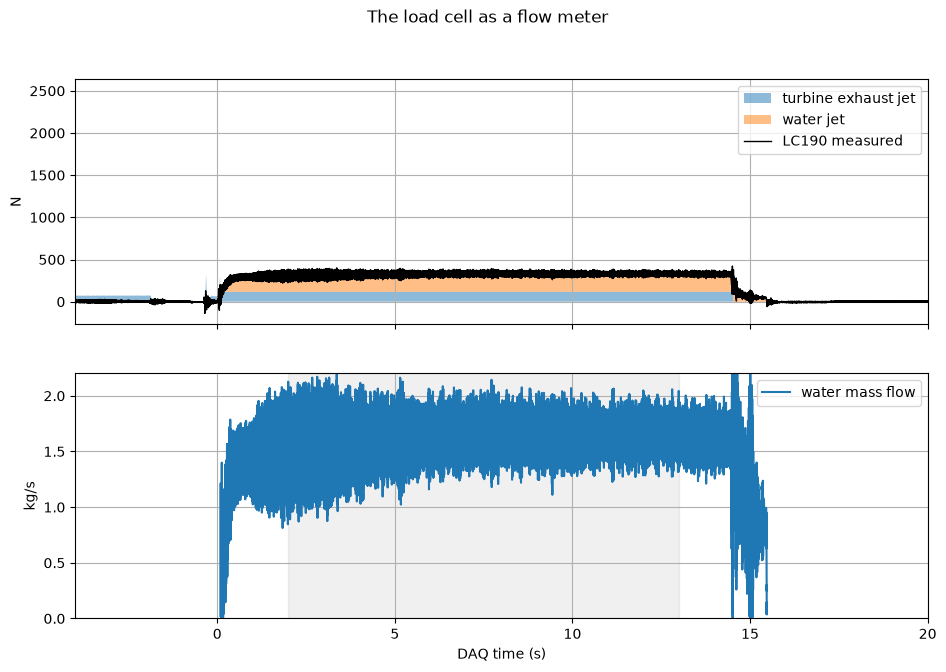

In [4]:
F = run["thrust"]
dp_or = run["dp_orifice"]
mdot_gas = run["mdot_gg_ox"].v + run["mdot_gg_fuel"].at(run["mdot_gg_ox"].t)
t_g = run["mdot_gg_ox"].t

V = ot2.JET_CV * np.sqrt(np.clip(2 * dp_or.at(F.t) * BAR / ot2.WATER_RHO, 0, None))
F_gas = np.interp(F.t, t_g, mdot_gas) * ot2.TURBINE_EXIT_VELOCITY
F_water = F.v - F_gas

fig, axs = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axs[0].fill_between(F.t, 0, F_gas, alpha=0.5, label="turbine exhaust jet")
axs[0].fill_between(F.t, F_gas, F_gas + np.clip(F_water, 0, None), alpha=0.5,
                    label="water jet")
axs[0].plot(F.t, F.v, "k", lw=1, label="LC190 measured")
axs[0].set_ylabel("N"); axs[0].legend(loc="upper right"); axs[0].grid(True)

Q = run["Q_pump"]
axs[1].plot(Q.t, Q.v * ot2.WATER_RHO, label="water mass flow")
axs[1].set_ylabel("kg/s"); axs[1].set_xlabel("DAQ time (s)"); axs[1].grid(True)
axs[1].legend(loc="upper right"); axs[1].axvspan(*BURN, color="k", alpha=0.06)
axs[1].set_xlim(-4, 20); axs[1].set_ylim(0, 2.2)

mdot_w = Q.mean(*BURN) * ot2.WATER_RHO
A_eff = Q.mean(*BURN) / np.mean(V[(F.t > BURN[0]) & (F.t < BURN[1])])
print(f"burn mean water flow  {mdot_w:.3f} kg/s  ({Q.mean(*BURN)*1e3:.3f} L/s)")
print(f"effective jet area    {A_eff*1e6:.2f} mm^2  "
      f"(d_eq {np.sqrt(4*A_eff/np.pi)*1e3:.2f} mm)")
A5 = np.pi/4 * ot2.ORIFICE_DIAMETER_ASSUMED**2
print(f"-> on a {ot2.ORIFICE_DIAMETER_ASSUMED*1e3:.0f} mm hole that is "
      f"Cd = {A_eff/A5:.3f}, the textbook sharp-edged value")
fig.suptitle("The load cell as a flow meter");

**Sensitivity.** The one modelled input is the turbine exit velocity used to
strip the gas jet. It enters as a subtraction, so it matters:

In [5]:
for v_gas in (500.0, 600.0, 655.0, 700.0, 800.0):
    fg = np.interp(F.t, t_g, mdot_gas) * v_gas
    a = (F.v - fg) / (ot2.WATER_RHO * np.clip(V, 1, None)**2)
    m = (F.t > BURN[0]) & (F.t < BURN[1])
    mw = ot2.WATER_RHO * np.mean(a[m] * V[m])
    print(f"  V_gas {v_gas:5.0f} m/s  ->  {mw:6.3f} kg/s  "
          f"({mw/mdot_w-1:+6.1%})")
print("\nEverything else in the chain is directly measured.")

  V_gas   500 m/s  ->   1.852 kg/s  (+13.0%)
  V_gas   600 m/s  ->   1.715 kg/s  ( +4.6%)
  V_gas   655 m/s  ->   1.639 kg/s  ( -0.0%)
  V_gas   700 m/s  ->   1.577 kg/s  ( -3.8%)
  V_gas   800 m/s  ->   1.440 kg/s  (-12.2%)

Everything else in the chain is directly measured.


## 4 - The operating point

In [6]:
window = SteadyWindow(run_id=run.run_id, label="steady burn", t0=BURN[0],
                      t1=BURN[1], reason="clear of both transients")
liquid = LiquidState(name="water", rho=ot2.WATER_RHO, nu=1.14e-6,
                     p_vap_bar=0.0171, p0_bar=run["p_pump_in"].mean(*BURN),
                     T_K=288.15,
                     source="15 degC assumed: TC140/TC141 dead on this run")
point = reduce_point(run, window, liquid, gg_R=ot2.GG_R, gg_gamma=ot2.GG_GAMMA,
                     gg_T0_K=ot2.GG_DESIGN_GAS.T0_K,
                     gas_source="measured p_c, DESIGN R and gamma (MR 0.5)")
point.p_turbine_exit = ot2.AMBIENT_BAR
print(point)

ObservedPoint
  run_id                                             20260701-111                    source run
  campaign                                                   OT-2                    source campaign
  t0                                                            2 s                  window start
  t1                                                           13 s                  window end
  rpm                                                    2.97e+04 RPM                shaft speed
  rpm_sd                                                      183 RPM                scatter over the window
  rpm_source         blade-passing ridge in 15000-19000 Hz / 3...                    how speed was obtained
  Q                                                       0.00164 m^3/s    1.64 L/s  pump volume flow
  mdot_pump                                                  1.64 kg/s               pump mass flow
  p_pump_in                                                  17.5 bar          

### What it implies about the hardware

The impeller diameter is not published, but the measured point implies it through
Barske's head relation. Worth checking against the drawing - if it matches, the
correlation is already close on this machine.

In [7]:
Q_, N_, H_ = point.Q, point.rpm, point.H_total
omega = rpm_to_rad(N_)
print(f"Q {Q_*1e3:.3f} L/s   N {N_:.0f} rpm   dp {point.dp_pump:.2f} bar   "
      f"H {H_:.0f} m")
print(f"useful power  Q dp = {Q_*point.dp_pump*BAR/1000:.2f} kW")
print(f"specific speed      = {N_*np.sqrt(Q_)/H_**0.75:.1f}  (rpm, m3/s, m)")
print()
for psi in (0.1, 0.2, 0.3):
    u2 = np.sqrt(2*g*H_/(1+psi))
    print(f"  psi {psi:.1f} -> u2 {u2:6.1f} m/s -> d2 {2*u2/omega*1e3:5.1f} mm")

Q 1.642 L/s   N 29711 rpm   dp 73.84 bar   H 754 m
useful power  Q dp = 12.13 kW
specific speed      = 8.4  (rpm, m3/s, m)

  psi 0.1 -> u2  116.0 m/s -> d2  74.6 mm
  psi 0.2 -> u2  111.0 m/s -> d2  71.4 mm
  psi 0.3 -> u2  106.7 m/s -> d2  68.6 mm


## 5 - The burn resolved in time

Legitimately, this time: the machine holds one point, so these windows are repeat
measurements of it rather than a sweep. A pump curve needs runs at different
throttle settings, not this run.

dp follows N^2 to 0.2% RMS
Q/N varies by 7.4% across the burn


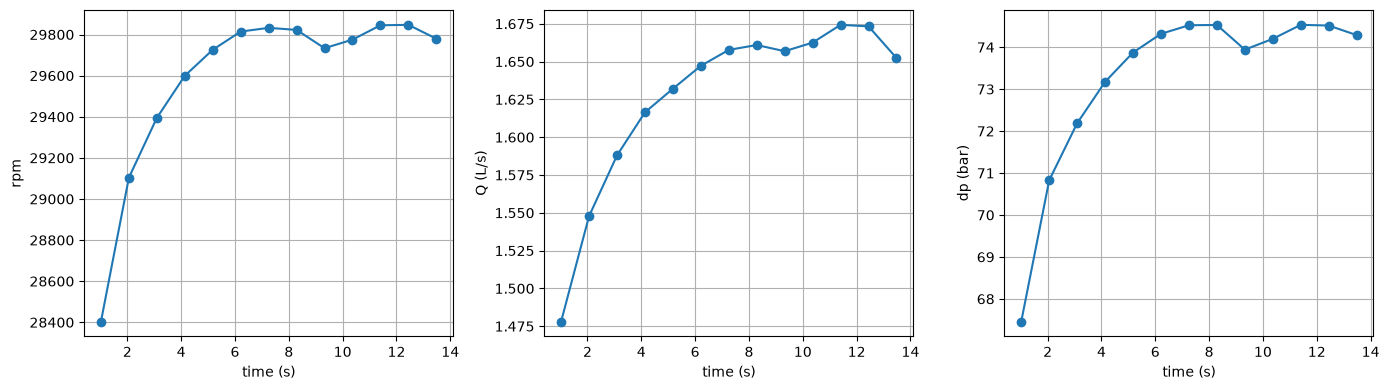

In [8]:
pts = reduce_series(run, liquid, t0=0.5, t1=14.0, n=13, gg_R=ot2.GG_R,
                    gg_gamma=ot2.GG_GAMMA, gg_T0_K=ot2.GG_DESIGN_GAS.T0_K)
good = [p for p in pts if None not in (p.Q, p.rpm, p.dp_pump)]
N = np.array([p.rpm for p in good])
Q = np.array([p.Q for p in good])
dp = np.array([p.dp_pump for p in good])
tm = np.array([(p.t0+p.t1)/2 for p in good])

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].plot(tm, N, "o-"); axs[0].set_ylabel("rpm")
axs[1].plot(tm, Q*1e3, "o-"); axs[1].set_ylabel("Q (L/s)")
axs[2].plot(tm, dp, "o-"); axs[2].set_ylabel("dp (bar)")
for ax in axs:
    ax.set_xlabel("time (s)"); ax.grid(True)

pred = dp[-1]*(N/N[-1])**2
print(f"dp follows N^2 to {np.sqrt((((pred-dp)/dp)**2).mean())*100:.1f}% RMS")
print(f"Q/N varies by {np.ptp(Q/N)/np.mean(Q/N)*100:.1f}% across the burn")
fig.tight_layout();

## 6 - The turbine model against the measurement

Mass flow only. Neither rig has a torque sensor, so the only power number on the
measured side is the pump's useful hydraulic power - a different quantity from
turbine shaft power by the whole of the pump's internal losses and the bearing
and seal drag.

In [9]:
print(compare_turbine(point, ot2.RIG.turbine, model="OT-2 mean line").table())

perf = ot2.RIG.turbine.point_performance(rpm=point.rpm, gas=point.gas,
                                         p_exit_bar=ot2.AMBIENT_BAR)
P_useful = point.Q * point.dp_pump * BAR
print(f"\nturbine net {perf.P_shaft/1000:.2f} kW, torque {perf.torque:.2f} Nm, "
      f"u/c_is {perf.u_over_c_is:.3f}")
print(f"pump useful {P_useful/1000:.2f} kW -> implied overall pump efficiency "
      f"{P_useful/perf.P_shaft*100:.0f}%")
print("A Barske at this specific speed belongs in the 25-40% band, so the two")
print("halves are consistent. It is a weak test while the loss coefficients")
print("are still placeholders.")

20260701-111  [OT-2 mean line]  2.00-13.00s
  quantity          measured       model     error  units
  mdot_gg             0.1781       0.153    -14.1%  kg/s
  not measured: P_shaft (no torque measurement on this rig)
  ! u/c_is = 0.097 is far below the impulse optimum (~0.5); most of the jet kinetic energy leaves unused, which is why the isentropic efficiency is low

turbine net 35.08 kW, torque 11.28 Nm, u/c_is 0.097
pump useful 12.13 kW -> implied overall pump efficiency 35%
A Barske at this specific speed belongs in the 25-40% band, so the two
halves are consistent. It is a weak test while the loss coefficients
are still placeholders.


## 7 - Where next

1. **CEA at the measured MR.** This window ran at MR 1.62; `gg_out.yaml`'s `R`
   and `gamma` are the MR-0.5 design values. The model under-predicts gas flow by
   14% and `Cd` is already 1.0, so no discharge coefficient can close it. This
   also explains the ~1500 K thermocouples against a 970 K design T0.
2. **Measure the orifice.** It turns section 3's cross-check into a genuine
   second route rather than a consistency argument.
3. **Pump geometry as a `PumpGeometry`**, to run the correlation against this
   point instead of inferring `d2` from it.
4. **Water temperature.** TC140 and TC141 were dead, so density is assumed. Weak
   dependence, but an assumption.
5. **A torque sensor on any future build.** Everything about efficiency here is
   inferred through the turbine model.